In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r'archive/Breast_GSE45827.csv')

In [4]:
df.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [5]:
df.shape

(151, 54677)

In [6]:
df.drop(columns=['samples'])
X=df.iloc[:,1:]
Y=df.iloc[:,1]

In [7]:
print(Y.unique())

['basal' 'HER' 'cell_line' 'normal' 'luminal_A' 'luminal_B']


In [8]:
print(Y.value_counts())

type
basal        41
HER          30
luminal_B    30
luminal_A    29
cell_line    14
normal        7
Name: count, dtype: int64


In [9]:
df = df[df["type"].isin(["basal", "luminal_A", "luminal_B"])]
df["type"] = df["type"].replace({
    "luminal_A": "luminal",
    "luminal_B": "luminal"
})
df.drop(columns=['samples'])
X=df.iloc[:,2:]
Y=df.iloc[:,1]
Y=Y.map({
    "basal":1,
    "luminal":0
})


In [10]:
Y.value_counts()

type
0    59
1    41
Name: count, dtype: int64

In [11]:
X.shape

(100, 54675)

Feature Selection: Remove those features (genes in our cases) that barely vary.

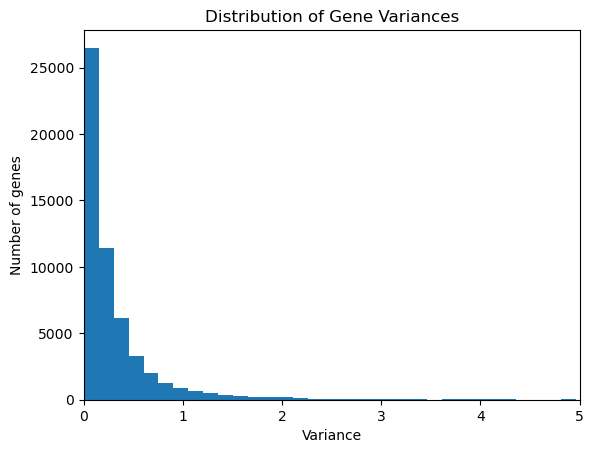

In [12]:
variances = np.var(X, axis=0)
plt.hist(variances, bins=100)
plt.xlim(0, 5)
plt.xlabel("Variance")
plt.ylabel("Number of genes")
plt.title("Distribution of Gene Variances")
plt.show()

Clearly, most of the genes have very low variance. These genes can be removed for analysis. Mainly the genes with variance <1. 

In [13]:
mask = variances >= 1
X_filtered = X.loc[:, mask]
print(X_filtered.shape)

(100, 3392)


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
def PCA_required(n):
    pca = PCA(n_components=n)
    X = pca.fit_transform(X_scaled)
    explained = np.cumsum(pca.explained_variance_ratio_)
    plt.plot(explained)
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.title("PCA Explained Variance")
    plt.show()
    return X
    

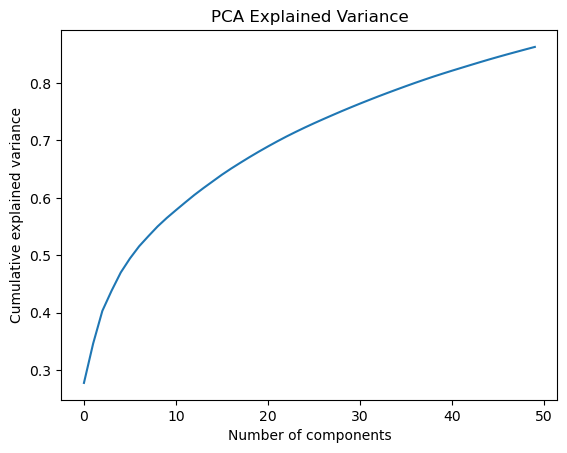

In [15]:
X=PCA_required(50)

The flattening of the curve:- With every new component added, the information retained from the original data is basically not increasing by a lot. 0.8 is a good figure. 

In [16]:
X_df=pd.DataFrame(X)
Y_df=pd.DataFrame(Y)

#X_df.to_csv("X.csv",header='FALSE',index='FALSE')
#Y_df.to_csv("Y.csv",header='FALSE',index='FALSE')

Checking for null values as it wasn't done before

In [17]:
print(X_df.isnull().sum().sum())

0


In [18]:
print(Y_df.isnull().sum().sum())

0


2nd part: PCA reduction to 100 features. 

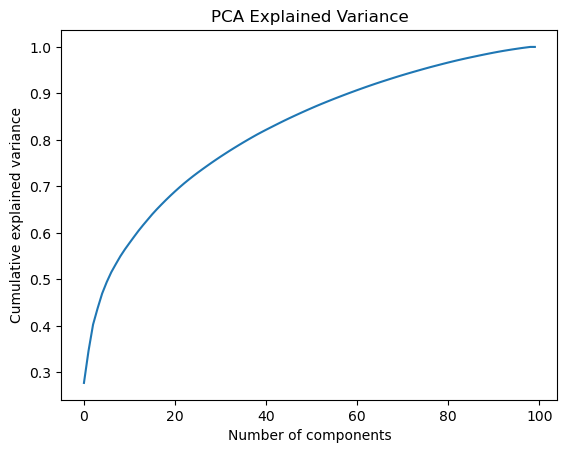

In [19]:
X1=PCA_required(100)

In [21]:
X1_df=pd.DataFrame(X1)
X1_df.shape

(100, 100)

In [22]:
print(X1_df.isnull().sum().sum())

0


In [24]:
X1_df.to_csv("X1.csv",header='FALSE',index='FALSE')
